# JAK1 Inhibitor Screening — Exploratory Data Analysis

This notebook explores the dataset used to train an XGBoost classifier that predicts whether a
compound is an **active JAK1 inhibitor** from its molecular descriptors.

The full, leakage-free modeling pipeline lives in [`../src/xgb_pipeline.py`](../src/xgb_pipeline.py).
This notebook focuses on understanding the data before modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/drug_descriptors_normalized.csv")
print(f"Shape: {df.shape[0]} compounds x {df.shape[1]} columns")
df.head()

Shape: 719 compounds x 1876 columns


,nAcid,ALogP,ALogp2,AMR,apol,naAromAtom,nAromBond,nAtom,nHeavyAtom,nH,...,P2s,E1s,E2s,E3s,Ts,As,Vs,Ks,Ds,Active
0,0.0,0.695872,0.013019,0.544758,0.382688,0.807692,0.814815,0.307692,0.478261,0.125000,...,0.566854,0.703079,0.345720,0.568567,0.062149,0.080140,0.161454,0.261691,0.519240,1.0
1,0.0,0.578387,0.005474,0.325013,0.298812,0.576923,0.592593,0.282051,0.304348,0.250000,...,0.226897,0.455912,0.152702,0.446377,0.279413,0.230434,0.272580,0.731193,0.215736,1.0
2,0.0,0.607230,0.000772,0.284210,0.233581,0.576923,0.592593,0.205128,0.217391,0.208333,...,0.241880,0.439424,0.208469,0.704403,0.242018,0.176320,0.207214,0.727763,0.382984,1.0
3,0.0,0.486290,0.049035,0.328994,0.301212,0.576923,0.592593,0.282051,0.260870,0.291667,...,0.130032,0.484617,0.253427,0.569702,0.318721,0.267276,0.341097,0.766607,0.356184,1.0
4,0.0,0.426009,0.101092,0.365912,0.368844,0.576923,0.592593,0.358974,0.304348,0.375000,...,0.080627,0.505470,0.162656,0.788421,0.434464,0.327603,0.364974,0.877562,0.437793,1.0


## Target: class distribution

`Active` is the binary label (1 = active JAK1 inhibitor, 0 = inactive). The classes are imbalanced,
which is why we track Precision/Recall/F1/AUC rather than accuracy alone, and compare against
naive baselines in the pipeline.

Active
0.0    191
1.0    528
Name: count, dtype: int64
Positive rate: 73.4%


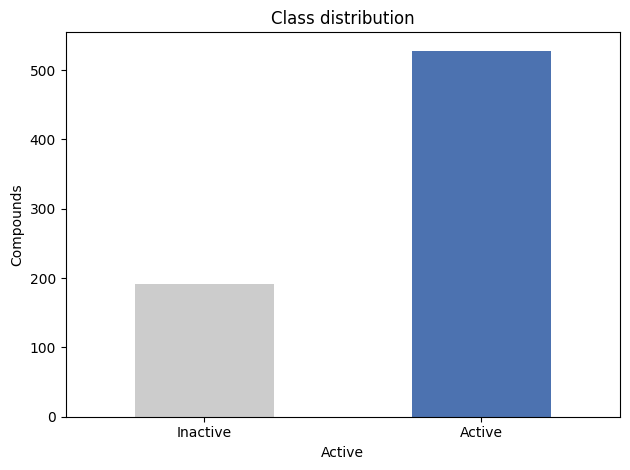

In [2]:
counts = df["Active"].value_counts().sort_index()
print(counts)
print(f"Positive rate: {counts.get(1,0) / counts.sum():.1%}")

counts.rename({0: "Inactive", 1: "Active"}).plot.bar(rot=0, color=["#cccccc", "#4c72b0"])
plt.title("Class distribution")
plt.ylabel("Compounds")
plt.tight_layout()
plt.show()

## Feature space: molecular descriptors

Each compound is described by ~1,875 normalized molecular descriptors. With far more features than
samples (719), feature selection and regularization matter. Below: how many descriptors carry
meaningful variance, and which correlate most strongly with activity.

In [3]:
X = df.drop(columns=["Active"])
y = df["Active"]

variances = X.var()
print(f"Total descriptors: {X.shape[1]}")
print(f"Descriptors with variance > 0.01: {(variances > 0.01).sum()}")
print(f"Near-constant descriptors (variance <= 1e-6): {(variances <= 1e-6).sum()}")

Total descriptors: 1875
Descriptors with variance > 0.01: 1464
Near-constant descriptors (variance <= 1e-6): 296


/Users/zhengyuhsiang/Library/Python/3.9/lib/python/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/zhengyuhsiang/Library/Python/3.9/lib/python/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


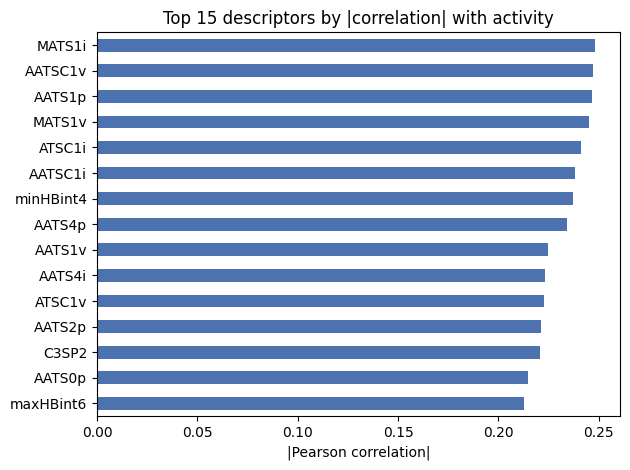

MATS1i       0.248207
AATSC1v      0.247245
AATS1p       0.246905
MATS1v       0.245010
ATSC1i       0.241183
AATSC1i      0.238224
minHBint4    0.237192
AATS4p       0.234230
AATS1v       0.224947
AATS4i       0.223052
ATSC1v       0.222506
AATS2p       0.221053
C3SP2        0.220837
AATS0p       0.214674
maxHBint6    0.212561
dtype: float64

In [4]:
corr = X.corrwith(y).abs().sort_values(ascending=False)
top = corr.head(15)[::-1]

top.plot.barh(color="#4c72b0")
plt.title("Top 15 descriptors by |correlation| with activity")
plt.xlabel("|Pearson correlation|")
plt.tight_layout()
plt.show()
top[::-1]

## Modeling

Modeling is handled by the consolidated pipeline so results are reproducible from the command line:

```bash
python ../src/xgb_pipeline.py              # 5-fold cross-validation (leakage-free headline metric)
python ../src/xgb_pipeline.py --train      # grid search -> save best model -> held-out test report
python ../src/xgb_pipeline.py --plots      # save ROC / confusion-matrix / feature-importance figures
```

**Note on evaluation.** An earlier version evaluated a pre-trained model on splits drawn from the
whole dataset, leaking training rows into the test set and inflating Test AUC to ~1.0. The pipeline
now defaults to stratified k-fold cross-validation (a fresh model per fold, scored only on the
held-out fold), giving a trustworthy **AUC ~0.86**. See the project README for the full results table.